In [ ]:
!pip install --upgrade tensorflow scikit-learn pandas numpy==1.26.4 matplotlib seaborn

In [ ]:
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Deep Learning framework imports (TensorFlow/Keras)
import tensorflow as tf

keras = tf.keras
layers = tf.keras.layers

EarlyStopping = tf.keras.callbacks.EarlyStopping
ReduceLROnPlateau = tf.keras.callbacks.ReduceLROnPlateau
to_categorical = tf.keras.utils.to_categorical

**1. Pengabaian Peringatan (Warnings)**
* import warnings: Memanggil modul pembawa sistem peringatan Python.
* warnings.filterwarnings('ignore'): Berfungsi untuk menyembunyikan pesan peringatan (warning) yang tidak penting agar tampilan layar kode tetap bersih saat dijalankan.

**2. Alat Pengolah Data dan Grafik**
* matplotlib.pyplot (plt): Alat untuk membuat grafik dasar, seperti grafik garis atau batang.
* numpy (np): Alat untuk mengolah angka dan operasi matematika dalam jumlah besar secara cepat.
* pandas (pd): Alat untuk membaca dan mengolah data berbentuk tabel (seperti file Excel atau CSV).
* seaborn (sns): Alat pelengkap untuk membuat grafik visual menjadi lebih indah dan rapi (misalnya peta warna/heatmap).

**3. Alat Evaluasi dari Scikit-Learn**
Scikit-learn adalah pustaka khusus untuk kecerdasan buatan. Di sini, kita mengambil fungsi untuk:

* train_test_split: Membagi data menjadi dua bagian: satu untuk melatih AI, dan satu untuk menguji kepintaran AI.
* StandardScaler: Mengubah skala angka pada data agar seragam (misalnya rentang 0 sampai 1) agar AI lebih mudah belajar.
* Fungsi Skor (precision_score, recall_score, f1_score, classification_report, confusion_matrix): Alat untuk mengukur dan melihat laporan seberapa akurat tebakan.

**4. Mesin Utama Jaringan Saraf (TensorFlow & Keras)**
Kode tersebut bertujuan untuk menyiapkan seluruh komponen penting sebelum membuat model kecerdasan buatan (Deep Learning).
1. program memanggil pustaka utama TensorFlow dan memberinya nama panggilan singkat agar lebih mudah digunakan nanti. Di dalam pustaka tersebut, program mengambil modul Keras yang berfungsi sebagai sistem utama pembuat model.

2. komponen layers sebagai bahan bangunan untuk menyusun struktur lapisan.

3. fungsi to_categorical yang berguna untuk mengubah format label data menjadi angka biner agar komputer bisa membacanya dengan mudah saat proses klasifikasi.

4. program mengaktifkan dua fitur pengawas otomatis untuk proses latihan, yaitu EarlyStopping yang akan langsung menghentikan latihan jika kecerdasan AI sudah maksimal agar hemat waktu, serta ReduceLROnPlateau yang otomatis memperkecil langkah belajar AI jika proses belajarnya mulai macet atau tidak menunjukkan kemajuan.

# LATAR BELAKANG
Epilepsi merupakan gangguan neurologis yang ditandai oleh aktivitas listrik abnormal pada otak. Salah satu metode yang umum digunakan untuk mendeteksi aktivitas epilepsi adalah Electroencephalography (EEG). Namun, interpretasi sinyal EEG secara manual memerlukan waktu dan keahlian khusus sehingga diperlukan pendekatan berbasis machine learning dan deep learning untuk membantu proses klasifikasi secara otomatis.

Pada penelitian ini digunakan Bangalore EEG Epilepsy Dataset (BEED) yang berisi 16 channel sinyal EEG dan empat kategori kondisi yaitu Healthy Subject, Generalized Seizure, Focal Seizure, dan Seizure Event. Tujuan penelitian adalah membangun model klasifikasi yang mampu mengidentifikasi kondisi epilepsi berdasarkan pola aktivitas listrik otak.

In [ ]:
df = pd.read_csv("/content/BEED_Data.csv")
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0


In [ ]:
total_baris = df.shape[0]
total_kolom = df.shape[1]

jumlah_fitur = total_kolom - 1

print("Jumlah data   :", total_baris, "baris")
print("Jumlah fitur  :", jumlah_fitur, "kolom")

Jumlah data   : 8000 baris
Jumlah fitur  : 16 kolom


Kode ini berfungsi untuk menghitung dan menampilkan jumlah baris data serta jumlah fitur (variabel) yang ada di dalam dataset df.

In [ ]:
total_data_kosong = df.isnull().sum().sum()

print("Missing value :", total_data_kosong, "data kosong")

Missing value : 0 data kosong


Kode ini berfungsi untuk menghitung total seluruh nilai yang kosong (missing values) di semua baris dan kolom dataset

In [ ]:
nama_kelas = {
    0: "Sehat",
    1: "Kejang Umum",
    2: "Kejang Fokal",
    3: "Kejang + Aktivitas"
}

print("Jumlah data per kelas:")
for kelas, jumlah in df['y'].value_counts().sort_index().items():
    print(f"  Kelas {kelas} ({nama_kelas[kelas]:20s}): {jumlah} sampel")


Jumlah data per kelas:
  Kelas 0 (Sehat               ): 2000 sampel
  Kelas 1 (Kejang Umum         ): 2000 sampel
  Kelas 2 (Kejang Fokal        ): 2000 sampel
  Kelas 3 (Kejang + Aktivitas  ): 2000 sampel


Kode ini digunakan untuk melihat distribusi label pada kolom target y (misalnya diagnosis medis) guna memastikan apakah jumlah data antar kelas seimbang atau tidak. Berdasarkan output, data sangat seimbang karena masing-masing memiliki tepat 2000 sampel.

In [ ]:
print("Statistik deskriptif fitur:")
print(df.describe().round(2))

Statistik deskriptif fitur:
            X1       X2       X3       X4       X5       X6       X7       X8  \
count  8000.00  8000.00  8000.00  8000.00  8000.00  8000.00  8000.00  8000.00   
mean     -1.49    -2.19    -3.24    -4.12    -1.82    -2.31    -3.40    -3.45   
std      36.82    36.11    35.80    36.29    37.62    36.31    36.36    36.52   
min    -281.00  -255.00  -255.00  -257.00  -264.00  -277.00  -277.00  -260.00   
25%      -7.00    -7.00    -7.00   -10.00   -10.00    -8.00    -8.00    -7.00   
50%       0.00     0.00    -1.00    -1.00     0.00     0.00    -1.00    -1.00   
75%       8.00     8.00     5.00     7.00    10.00     8.00     6.00     5.00   
max     252.00   261.00   238.00   246.00   249.00   245.00   220.00   271.00   

            X9      X10      X11      X12      X13      X14      X15      X16  \
count  8000.00  8000.00  8000.00  8000.00  8000.00  8000.00  8000.00  8000.00   
mean     -1.65    -2.56    -3.52    -4.78    -2.16    -2.91    -4.36    -4.11   

count: Jumlah data yang terisi. Semua bernilai 8000.00, menandakan tidak ada data yang kosong.

(missing values) pada fitur-fitur ini.mean: Nilai rata-rata dari setiap kolom.std

(Standard Deviation): Tingkat penyebaran data. Nilai std pada \(X1\)–\(X16\) cukup besar (sekitar 35–38), artinya data cukup bervariasi.

min & max: Nilai terendah dan tertinggi dalam kolom.

25%, 50%, 75% (Kuartil):
50% adalah median (nilai tengah data).
Separuh data pada hampir semua fitur (X) bernilai di sekitar 0.00 atau -1.00.

#Why Dataset BEED?
Dataset BEED dipilih karena menyediakan data EEG yang seimbang pada empat kategori kondisi epilepsi. Selain itu, dataset memiliki 16 channel EEG yang merepresentasikan aktivitas berbagai area otak sehingga cocok digunakan untuk penelitian klasifikasi epilepsi berbasis deep learning.

Dataset ini juga memiliki jumlah data yang cukup besar yaitu 8.000 data sehingga memungkinkan model untuk mempelajari pola aktivitas otak secara lebih baik.

# EKSPLORASI DATA SECARA VISUAL (EDA)

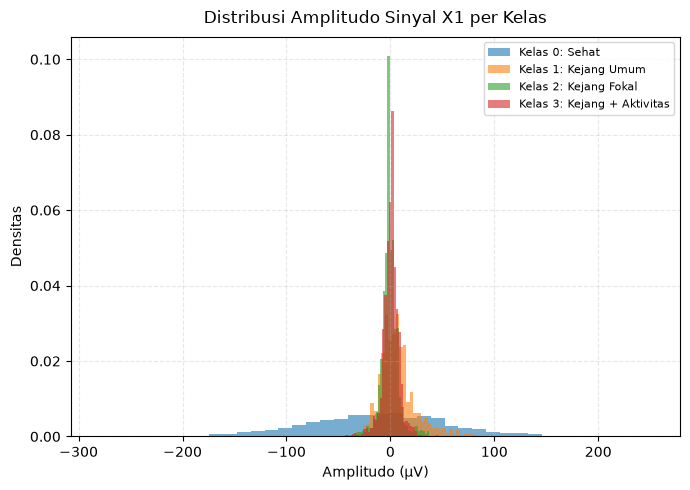

In [ ]:
# Cek perbedaan sebaran nilai amplitudo X1 di setiap kelompok
plt.figure(figsize=(7, 5))

for k in range(4):
    subset = df[df['y'] == k]['X1']
    plt.hist(subset, bins=40, alpha=0.6, label=f"Kelas {k}: {nama_kelas[k]}", density=True)

plt.title("Distribusi Amplitudo Sinyal X1 per Kelas", fontsize=12, pad=10)
plt.xlabel("Amplitudo (μV)")
plt.ylabel("Densitas")
plt.legend(fontsize=8)
plt.grid(axis='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


menampilkan grafik histogram hasil eksekusi kode sebelumnya, yang membandingkan distribusi amplitudo sinyal X1 untuk empat kelas kondisi medis.

**Analisis Hasil Grafik**

* Kelas 0 (Sehat - Biru): Memiliki distribusi yang paling lebar dan landai (menyebar luas dari kisaran -200 hingga +100 $\mu$V). Nilai densitasnya sangat rendah, menunjukkan variasi nilai amplitudo yang tinggi atau sinyal yang lebih dinamis/acak.

* Kelas 1 (Kejang Umum - Oranye): Berpusat sangat rapat di sekitar angka 0, namun memiliki sedikit kemiringan (skewness) atau distribusi yang sedikit lebih tebal di sisi kanan (nilai positif kecil) dibanding kelas fokal dan aktivitas.

* Kelas 2 (Kejang Fokal - Hijau) & Kelas 3 (Kejang + Aktivitas - Merah): Kedua kelas ini memiliki pola distribusi yang sangat mirip, lancip, dan tinggi (terpusat tajam) tepat di sekitar angka 0 $\mu$V. Ini menandakan bahwa pada fitur X1, mayoritas sinyal untuk kedua kondisi kejang ini bernilai sangat kecil atau mendekati nol.


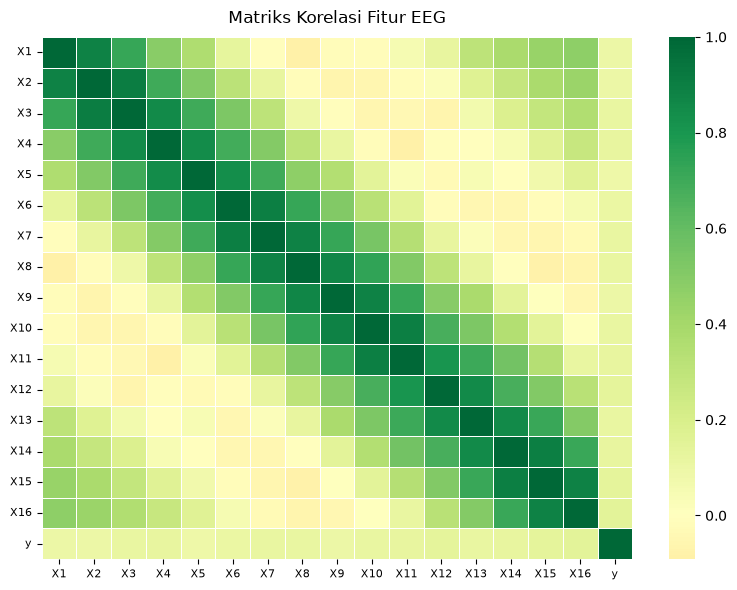

In [ ]:
# Hitung korelasi antar semua fitur EEG
matrix_korelasi = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matrix_korelasi, cmap='RdYlGn', center=0, linewidths=0.5, annot=False)

plt.title("Matriks Korelasi Fitur EEG", fontsize=12, pad=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()


Fitur yang letaknya berdekatan (misal \(X1\) dengan \(X2\), \(X8\) dengan \(X9\)) memiliki korelasi hijau tua yang sangat kuat (mendekati 1.0).

banyak fitur tetangga yang berkorelasi sangat tinggi, artinya beberapa fitur membawa informasi yang hampir sama.


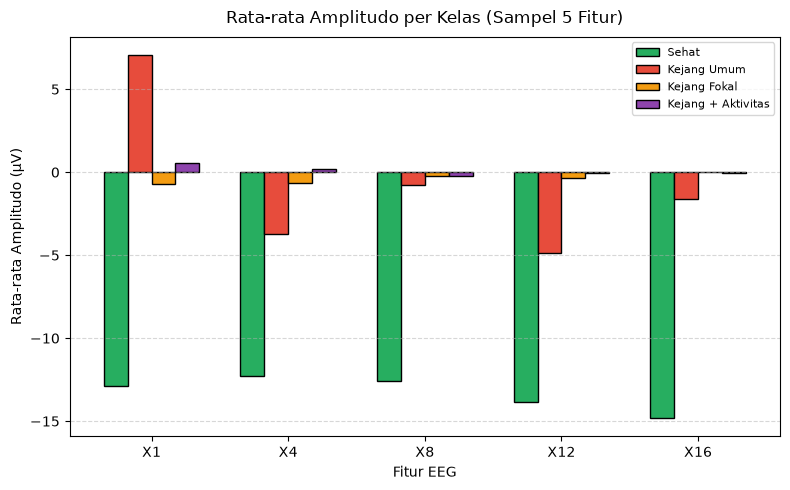

In [ ]:
# Ambil sampel 5 fitur untuk melihat perbedaan rata-rata nilai antar kelas
fitur_pilihan = ['X1', 'X4', 'X8', 'X12', 'X16']
rata_rata = df.groupby('y')[fitur_pilihan].mean()
colors = ['#27ae60', '#e74c3c', '#f39c12', '#8e44ad']

# transpose (.T) agar fitur berada di sumbu X
ax = rata_rata.T.plot(kind='bar', figsize=(8, 5), color=colors, edgecolor='black', width=0.7)

plt.title("Rata-rata Amplitudo per Kelas (Sampel 5 Fitur)", fontsize=12, pad=10)
plt.xlabel("Fitur EEG")
plt.ylabel("Rata-rata Amplitudo (μV)")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Ambil label legenda langsung dari nama kelas yang sudah didefinisikan sebelumnya
plt.legend([nama_kelas[i] for i in range(4)], fontsize=8)

plt.tight_layout()
plt.show()


**1. Kelas Sehat (Hijau) Memiliki Karakteristik Paling Unik**
Sinyal dari kelompok Sehat secara konsisten menunjukkan rata-rata amplitudo negatif yang sangat kuat (berkisar antara -12 hingga -15 μV) di seluruh sampel fitur ($X1$, $X4$, $X8$, $X12$, $X16$). Ini menjadi pembeda linear yang sangat jelas dibandingkan dengan tiga kelompok kejang lainnya.

**2. Lonjakan Ekstrem pada Kelas Kejang Umum (Merah) di Fitur $X1$**
Pada fitur $X1$, kelompok Kejang Umum mengalami lonjakan nilai rata-rata positif yang sangat tinggi (di atas +5 μV), sementara fitur-fitur lainnya cenderung negatif atau mendekati nol. Pola kontras yang ekstrem ini membuat fitur $X1$ menjadi salah satu prediktor paling krusial bagi ANN untuk mendeteksi jenis Kejang Umum.

**3. Kelas Kejang Fokal (Oranye) dan Kejang + Aktivitas (Ungu) Sulit Dibedakan**
Pada hampir semua fitur yang disampel (terutama $X4$, $X8$, $X12$, dan $X16$), batang warna Oranye dan Ungu bernilai sangat kecil dan berimpit mendekati garis 0 μV.

* Tantangan Model: Nilai rata-rata yang hampir serupa ini menegaskan kembali mengapa kedua kelas kejang ini sulit dipisahkan pada analisis distribusi sebelumnya. Model ANN harus mengandalkan kombinasi pola non-linear dari seluruh 16 fitur secara simultan untuk mencari celah perbedaan terkecil di antara keduanya.



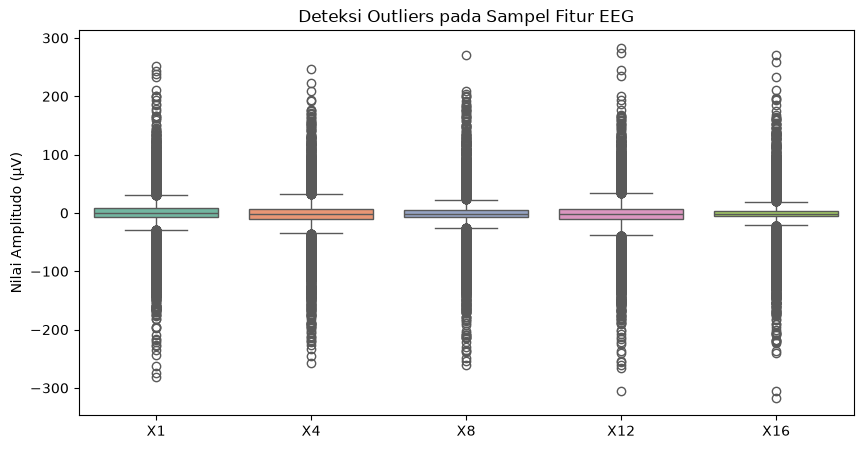

In [ ]:
plt.figure(figsize=(10, 5))
# Membuat box plot untuk melihat sebaran outliers di 5 fitur pilihan
sns.boxplot(data=df[['X1', 'X4', 'X8', 'X12', 'X16']], palette='Set2')

plt.title("Deteksi Outliers pada Sampel Fitur EEG", fontsize=12)
plt.ylabel("Nilai Amplitudo (μV)")
plt.show()


**Analisis Hasil Grafik**

Kotak Utama Sangat Pipih: Kotak utama (rentang kuartil 25% hingga 75%) berpusat sangat tipis di sekitar angka 0. Ini berarti mayoritas data asli  sebenarnya berkumpul rapat di rentang nilai yang kecil.

Ekor Bulatan Hitam Sangat Panjang: Bulatan-bulatan hitam di luar garis batas (whiskers) yang menjulur hingga melebihi +200 dan -300 adalah titik-titik outliers. Jumlahnya sangat padat, membentuk garis tebal vertikal.

# PREPROCESSING DATA

In [ ]:
# Pisahkan fitur dan target
X = df.drop(columns=['y']).values
y = df['y'].values

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")

Shape X: (8000, 16)
Shape y: (8000,)


Penggunaan .values otomatis mengubah data dari format Pandas DataFrame menjadi NumPy Array.

Output Shape X: (8000, 16) dan Shape y: (8000,) menunjukkan bahwa data terpisah dengan sempurna: 8000 baris sampel, 16 kolom input, dan 1 kolom target.

In [ ]:
# One-Hot Encoding target untuk ANN
y_encoded = to_categorical(y, num_classes=4)
print(f"Shape y setelah One-Hot Encoding: {y_encoded.shape}")

Shape y setelah One-Hot Encoding: (8000, 4)


Mengubah label kelas tunggal (0, 1, 2, 3) menjadi bentuk matriks biner berukuran (8000, 4).

In [ ]:
# Pembagian data(70% train, 15% validasi, 15% test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42,
    stratify=np.argmax(y_temp, axis=1)
)

print(f"Pembagian Data:")
print(f"  Training   : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validasi   : {X_val.shape[0]} sampel ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Testing    : {X_test.shape[0]} sampel ({X_test.shape[0]/len(X)*100:.1f}%)")

Pembagian Data:
  Training   : 5600 sampel (70.0%)
  Validasi   : 1200 sampel (15.0%)
  Testing    : 1200 sampel (15.0%)


# Normalisasi dengan RobustScaler

Metode RobustScaler adalah  salah  satu  teknik pre-processingdalam  analisis  data  yang  digunakan  untuk menormalkan data dengan mengurangi pengaruh outlier. Rumus RobustScaler yang digunakan :

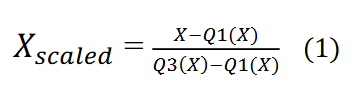

Data EEG mengandung banyak nilai ekstrem yang dapat berasal dari aktivitas kejang maupun noise. Oleh karena itu digunakan RobustScaler agar proses normalisasi tidak terlalu dipengaruhi oleh outlier.

In [ ]:
from sklearn.preprocessing import RobustScaler

# 1. Inisialisasi RobustScaler
scaler = RobustScaler()

# 2. Fit dan transform hanya pada data Training
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform pada data Validasi dan Testing
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Kode RobustScaler digunakan untuk menyeimbangkan data EEG yang penuh pencilan dengan cara menghitung median dan IQR dari data latih, lalu menerapkannya ke data validasi dan uji. Tujuannya adalah melindungi model dari outliers, mempercepat dan menstabilkan proses training ANN, serta mencegah kebocoran data dengan pemisahan fit dan transform. Hasilnya, semua fitur kini memiliki median 0 dengan rentang utama sekitar -1 hingga 1, sehingga data sudah siap dipakai untuk membangun arsitektur ANN.

# Pengecekkan apakah scaller berhasil

In [ ]:
# Cek median dari X_train_scaled
median_per_fitur = np.median(X_train_scaled, axis=0)

print("Median tiap fitur setelah scaling:")
print(np.round(median_per_fitur, 2))

Median tiap fitur setelah scaling:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
print("Sebelum diskalakan (X_train) - 2 baris pertama:")
print(X_train[:2])

print("\nSesudah diskalakan (X_train_scaled) - 2 baris pertama:")
print(np.round(X_train_scaled[:2], 2))


Sebelum diskalakan (X_train) - 2 baris pertama:
[[  3   2  13   7   3   9  11   2   4  17  12   0  12  16   9  -4]
 [  0 -18  -3  -7   4 -10  -8 -15  -6  -5  -7  -3  -8  -5 -11   4]]

Sesudah diskalakan (X_train_scaled) - 2 baris pertama:
[[ 0.21  0.13  1.17  0.47  0.2   0.56  0.86  0.25  0.27  1.    1.    0.06
   0.6   0.94  0.79 -0.3 ]
 [ 0.   -1.2  -0.17 -0.35  0.25 -0.62 -0.5  -1.17 -0.4  -0.29 -0.46 -0.11
  -0.4  -0.29 -0.64  0.5 ]]


# BAGIAN 2: PEMODELAN

**ANN (MLP)**

Multilayer Perceptron (MLP) merupakan salah satu jenis Artificial Neural Network (ANN) yang terdiri dari beberapa lapisan neuron, yaitu input layer, satu atau lebih hidden layer, dan output layer. Setiap neuron pada suatu layer terhubung dengan neuron pada layer berikutnya melalui bobot (weights) yang akan diperbarui selama proses pelatihan menggunakan algoritma backpropagation. MLP mampu mempelajari hubungan non-linear yang kompleks antar fitur sehingga banyak digunakan untuk tugas klasifikasi dan prediksi.

ANN MLP dipilih karena mampu mempelajari pola non-linear yang kompleks pada data EEG. Selain itu, MLP merupakan salah satu arsitektur neural network yang sederhana namun efektif sehingga dapat digunakan sebagai model dasar (baseline model) untuk mengevaluasi performa model yang lebih kompleks, yaitu Residual MLP.
Pada MLP kita menggunakan Relu untuk membantu model mempelajari hubungan non-linear yang terdapat pada sinyal EEG.

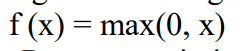

Selain itu, kita juga menggunakan Softmax pada output layer untuk menghasilkan probabilitas dari empat kelas yang akan diprediksi.
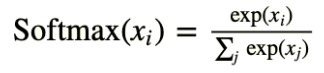

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

def buat_ann_mlp(input_dim=16, num_kelas=4):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # Lapisan tersembunyi 1: 128 neuron
        layers.Dense(128, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Lapisan tersembunyi 2: 64 neuron
        layers.Dense(64, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Lapisan tersembunyi 3: 32 neuron
        layers.Dense(32, activation='relu'),

        layers.Dense(num_kelas, activation='softmax')
    ], name='ANN_MLP')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

ann_mlp = buat_ann_mlp()
ann_mlp.summary()

Model: "ANN_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,412 (52.39 KB)

 Trainable params: 13,028 (50.89 KB)

 Non-trainable params: 384 (1.50 KB)

## Kolom Tabel

   1. Layer (type): Nama dan jenis lapisan yang digunakan untuk menyaring data.
   2. Output Shape: Ukuran data setelah keluar dari lapisan tersebut. Kata None berarti model ini fleksibel dan bisa menerima jumlah baris data (batch) berapa saja, sedangkan angka di sebelahnya adalah jumlah neuron/fitur.
   3. Param #: Jumlah "koneksi saraf" atau bobot yang dipelajari pada lapisan tersebut.

------------------------------
## Penjelasan Baris demi Baris

* dense (Dense) & (None, 128) & 2.176
Data awal (16 fitur) masuk ke lapisan pertama yang berisi 128 neuron. Di sini terbentuk 2.176 koneksi saraf untuk mengenali pola awal data.
* batch_normalization & (None, 128) & 512
Lapisan ini bertugas merapikan dan menstabilkan nilai data dari 128 neuron sebelumnya agar model tidak bingung saat belajar.
* dropout & (None, 128) & 0
Lapisan pelindung yang mematikan 30% neuron secara acak untuk mencegah overfitting (AI menghafal kunci jawaban). Lapisan ini tidak punya koneksi saraf baru (0).
* dense_1 & (None, 64) & 8.256
Informasi diperas lagi ke dalam 64 neuron. Di sini terjadi koneksi paling banyak (8.256) karena menghubungkan 128 neuron sebelumnya ke 64 neuron baru.
* batch_normalization_1 & dropout_1
Sama seperti sebelumnya, bagian ini berfungsi menstabilkan data dan melindungi model dari menghafal kaku pada level 64 neuron.
* dense_2 & (None, 32) & 2.080
Pola data diperhalus lagi dan disederhanakan menjadi 32 informasi penting sebelum masuk ke tahap keputusan.
* dense_3 & (None, 4) & 132
Lapisan Output (Keputusan Akhir). Mengubah 32 informasi penting menjadi 4 angka probabilitas (persentase) yang mewakili 4 kelas target/kategori penyakit.

------------------------------
## Arti Angka di Bagian Bawah

* Total params (13.412): Total seluruh koneksi saraf yang ada di dalam model.
* Trainable params (13.028): Jumlah koneksi yang aktif belajar dan nilainya akan terus berubah agar AI makin pintar selama pelatihan.
* Non-trainable params (384): Parameter konstan yang tidak ikut diubah saat latihan (berasal dari catatan statistik internal Batch Normalization).



In [ ]:
# ── Callback: perilaku otomatis selama training ───────────────────────────────
# EarlyStopping  : hentikan training jika val_loss tidak membaik selama 15 epoch
# ReduceLROnPlateau: turunkan learning rate jika val_loss macet

callbacks_mlp = [
    EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-6, verbose=1
    )
]

print("Mulai training ANN MLP...")
history_mlp = ann_mlp.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks_mlp,
    verbose=1
)
print("\nTraining selesai!")

Mulai training ANN MLP...
Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - accuracy: 0.5198 - loss: 1.0166 - val_accuracy: 0.6650 - val_loss: 0.8517 - learning_rate: 0.0010
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6582 - loss: 0.7354 - val_accuracy: 0.7575 - val_loss: 0.6672 - learning_rate: 0.0010
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7170 - loss: 0.6333 - val_accuracy: 0.7908 - val_loss: 0.5631 - learning_rate: 0.0010
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7600 - loss: 0.5668 - val_accuracy: 0.7967 - val_loss: 0.4911 - learning_rate: 0.0010
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7788 - loss: 0.5200 - val_accuracy: 0.8192 - val_loss: 0.4442 - learning_rate: 0.0010
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7954 - loss: 0.4821 - val_accuracy: 0.8358 - val_loss: 0.4082 - learning_rate: 0.0010
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.

proses training model ANN (Artificial Neural Network) dengan tambahan callback supaya prosesnya lebih pintar dan efisien.

EarlyStopping: otomatis menghentikan training kalau nilai val_loss (error pada data validasi) tidak membaik selama 15 epoch berturut-turut. Tujuannya agar model tidak buang-buang waktu melatih data yang sudah tidak memberi peningkatan.

ReduceLROnPlateau: kalau val_loss macet (tidak turun lagi), maka learning rate akan diturunkan setengahnya (factor=0.5). Ini membantu model belajar lebih hati-hati agar bisa menemukan titik optimal.

restore_best_weights=True: setelah training berhenti, bobot terbaik (yang menghasilkan val_loss paling rendah) akan dipulihkan.

fit(...): bagian ini menjalankan proses training ANN dengan data latih (X_train_scaled, y_train) dan mengecek hasilnya pada data validasi (X_val_scaled, y_val). Training dilakukan maksimal 100 epoch, batch size 64, tapi bisa berhenti lebih cepat kalau EarlyStopping aktif.

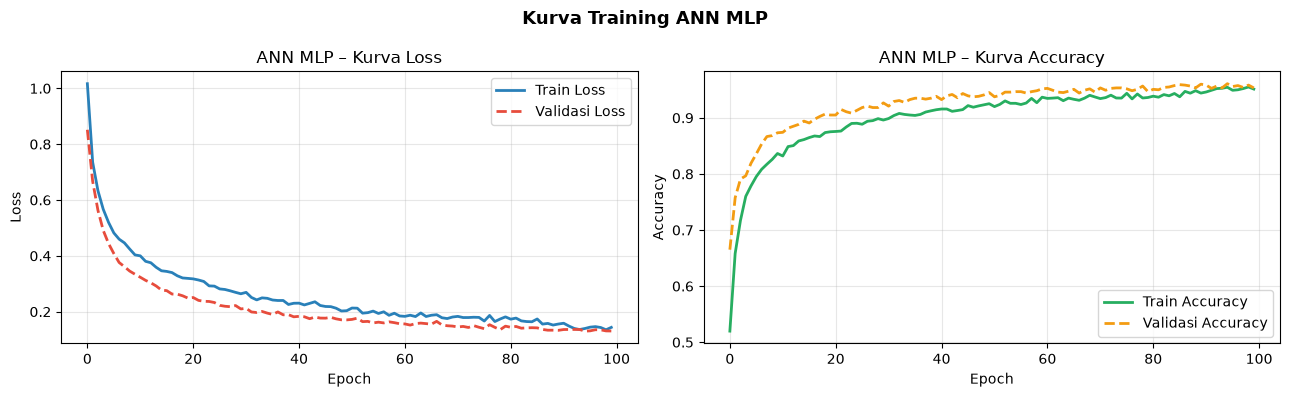

In [ ]:
# ── Visualisasi kurva training ANN MLP ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Grafik 1: Loss
axes[0].plot(history_mlp.history['loss'],
             label='Train Loss', color='#2980b9', linewidth=2)
axes[0].plot(history_mlp.history['val_loss'],
             label='Validasi Loss', color='#e74c3c', linewidth=2, linestyle='--')
axes[0].set_title('ANN MLP – Kurva Loss', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Grafik 2: Accuracy
axes[1].plot(history_mlp.history['accuracy'],
             label='Train Accuracy', color='#27ae60', linewidth=2)
axes[1].plot(history_mlp.history['val_accuracy'],
             label='Validasi Accuracy', color='#f39c12', linewidth=2, linestyle='--')
axes[1].set_title('ANN MLP – Kurva Accuracy', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Kurva Training ANN MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



1.   Kurva Loss

  Garis biru (Train Loss) dan garis putus-putus merah (Validasi Loss) terlihat terus menurun dengan mulus dari angka 0.9 hingga jatuh ke sekitar angka 0.14. Artinya, tingkat kesalahan model terus berkurang secara konsisten seiring bertambahnya waktu latihan.

2.   Kurva Accuracy

Garis hijau (Train Accuracy) dan garis putus-putus oranye (Validasi Accuracy) melonjak naik dengan cepat di awal putaran dan berakhir stabil di angka sekitar 0.95 (95%).
Model berhasil mencapai tingkat akurasi yang sangat tinggi, yaitu mampu menebak dengan benar sekitar 95% dari total data yang diberikan.

Pada grafik, garis latihan (Train) dan garis validasi (Validation) tampak berjalan beriringan dan menempel ketat hingga akhir epoch ke-100, menunjukkan **tidak adanya gejala overfitting**. Overfitting biasanya terjadi ketika model hanya unggul pada data latihan tetapi gagal pada data uji, yang ditandai dengan garis validasi merah naik kembali ke atas atau garis oranye tertinggal jauh di bawah, namun kondisi tersebut tidak terlihat pada hasil ini.


## MODEL 2: Residual MLP (ResMLP)

Residual Multilayer Perceptron (Residual MLP atau ResMLP) merupakan pengembangan dari Multilayer Perceptron (MLP) yang memanfaatkan konsep Residual Learning melalui mekanisme skip connection atau shortcut connection. Pada Residual MLP, informasi dari layer sebelumnya tidak hanya diteruskan melalui jalur utama, tetapi juga langsung diteruskan ke layer berikutnya melalui shortcut connection. Dengan demikian, informasi penting dari input dapat tetap dipertahankan selama proses pembelajaran.

Residual MLP dipilih karena memiliki mekanisme skip connection yang membantu model mempelajari pola aktivitas otak secara lebih efektif dibandingkan MLP standar. Selain itu, residual block mampu meningkatkan stabilitas training dan mengurangi risiko hilangnya informasi ketika jaringan menjadi lebih dalam.

Misalkan (X,y) adalah data masukan model yang mana X memiliki n1 fitur, terdiri dari (Xt,yt) (t=1,2,···,n) dan kita membangun model MLPRS dengan kedalaman k. MLP dalam model yang diusulkan memiliki satu lapisan tersembunyi, kita dapat memperoleh keluaran MLPRS sebagai berikut :

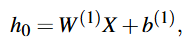

di mana h0 adalah keluaran lapisan masukan ResNet.

In [ ]:
# ── Fungsi pembangun satu Residual Block ──────────────────────────────────────
def residual_block(x, units, dropout_rate=0.3):
    # Simpan input asli sebagai jalur pintas
    shortcut = x

    # Jalur utama: dua lapisan Dense
    x = layers.Dense(units, kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(units, kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    # Projection shortcut: sesuaikan dimensi jika berbeda
    # Contoh: jika input punya 16 dimensi tapi blok menghasilkan 64 dimensi,
    # kita proyeksikan input ke 64 dimensi dulu sebelum dijumlahkan
    if shortcut.shape[-1] != units:
        shortcut = layers.Dense(units, use_bias=False)(shortcut)

    # Skip connection: jumlahkan jalur utama + jalur pintas
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x

print("Fungsi residual_block berhasil didefinisikan.")

Fungsi residual_block berhasil didefinisikan.


Residual Block
Residual block adalah blok bangunan jaringan yang punya jalur utama (main path) dan jalur pintas (shortcut).

Jalur utama: input diproses lewat beberapa lapisan (Dense, BatchNorm, ReLU, Dropout).

Jalur pintas: input asli dilewatkan langsung tanpa banyak perubahan.

Di akhir, hasil jalur utama ditambahkan dengan jalur pintas → ini disebut skip connection.

Tujuannya: menjaga informasi awal tetap ada, sekaligus menambahkan hasil transformasi baru. Dengan cara ini, jaringan bisa lebih dalam tanpa kehilangan informasi dan lebih mudah dilatih.

Bedanya dengan ANN Baseline
ANN Baseline: hanya susunan lapisan Dense biasa (input → hidden layer → output). Informasi selalu diproses berlapis-lapis tanpa jalur pintas.

ANN dengan Residual Block: ada tambahan shortcut yang langsung menghubungkan input ke output blok. Jadi informasi tidak “hilang” di tengah jalan, dan gradient saat training lebih stabil.

Hasilnya: model residual biasanya lebih kuat, bisa dilatih lebih dalam, dan lebih tahan terhadap masalah seperti vanishing gradient.

Analogi sederhana
ANN Baseline seperti jalan lurus: semua mobil harus melewati setiap pos pemeriksaan.

Residual Block seperti jalan tol dengan jalur cepat: ada mobil yang bisa langsung lewat pintas, tapi tetap digabung dengan mobil dari jalur utama. Jadi arus lebih lancar dan tidak macet.

In [ ]:
# ── Arsitektur lengkap Residual MLP ───────────────────────────────────────────
def buat_resmlp(input_dim=16, num_kelas=4):
    """
    Arsitektur ResMLP:

    Input(16)
        ↓
    Dense(64) ← lapisan proyeksi awal, memperbesar representasi
        ↓
    ResidualBlock(64)  ← blok 1 dengan skip connection
        ↓
    ResidualBlock(64)  ← blok 2 dengan skip connection
        ↓
    ResidualBlock(32)  ← blok 3, mempersempit representasi
        ↓
    GlobalAveragePooling (opsional, diganti Flatten)
        ↓
    Dense(4, Softmax) ← output 4 kelas
    """
    tf.random.set_seed(42)

    inputs = keras.Input(shape=(input_dim,), name='input_eeg')

    # Lapisan proyeksi awal: dari 16 fitur ke ruang 64 dimensi
    # Ini agar blok residual pertama punya cukup "ruang" untuk belajar
    x = layers.Dense(64, activation='relu', name='proyeksi_awal')(inputs)
    x = layers.BatchNormalization(name='bn_awal')(x)

    # Blok Residual 1 — 64 neuron
    x = residual_block(x, units=64, dropout_rate=0.3)

    # Blok Residual 2 — 64 neuron (memperdalam tanpa mengurangi dimensi)
    x = residual_block(x, units=64, dropout_rate=0.3)

    # Blok Residual 3 — 32 neuron (mempersempit, seperti funnel)
    x = residual_block(x, units=32, dropout_rate=0.2)

    # Output: klasifikasi 4 kelas
    outputs = layers.Dense(num_kelas, activation='softmax', name='output')(x)

    model = keras.Model(inputs, outputs, name='Residual_MLP')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

resmlp = buat_resmlp()
resmlp.summary()

Model: "Residual_MLP"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_eeg           │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proyeksi_awal       │ (None, 64)        │      1,088 │ input_eeg[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_awal             │ (None, 64)        │        256 │ proyeksi_awal[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ bn_awal[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      4,160 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64)        │          0 │ batch_normalizat… │
│                     │                   │            │ bn_awal[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64)        │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      4,160 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      4,160 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64)        │          0 │ batch_normalizat… │
│                     │                   │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64)        │          0 │ add_1[0][0]     

 Total params: 24,580 (96.02 KB)

 Trainable params: 23,812 (93.02 KB)

 Non-trainable params: 768 (3.00 KB)

1. Pintu Masuk (Input)
input_eeg: Data masuk ke model ini berjumlah 16 fitur. Karena bernama "eeg", kemungkinan besar ini adalah data sinyal otak dari 16 kanal atau 16 fitur yang diekstrak dari gelombang otak.

2. Persiapan Awal
proyeksi_awal (Dense): Model langsung "memperbesar" data dari 16 menjadi 64. Tujuannya agar model memiliki "ruang berpikir" atau dimensi yang lebih luas untuk menganalisis pola data.
bn_awal (Batch Normalization): Seperti mesin yang merapikan dan menstandarisasi data agar proses belajar AI menjadi lebih stabil dan cepat.

3. Inti Pembelajaran (Residual Blocks)
Ini adalah bagian terpenting dari model ini (sesuai namanya, Residual). Model ini memiliki dua blok pembelajaran yang berulang. Di dalam setiap blok ada:
Dense: Lapisan saraf tiruan utama yang mencari pola.
Batch Normalization: Penstabil data.
Activation: "Saklar" yang memutuskan apakah informasi ini penting untuk diteruskan atau tidak.
Dropout: Secara acak "mematikan" sebagian kecil saraf saat latihan. Ini adalah teknik pencegahan agar AI tidak sekadar "menghafal" data latihan, tapi benar-benar "paham" (mencegah overfitting).
Add (Jalan Pintas / Shortcut): Ini adalah ciri khas arsitektur Residual. Alih-alih data hanya mengalir lurus ke bawah, data dari lapisan sebelumnya "diloncatkan" dan ditambahkan (Add) ke lapisan sekarang. Analogi: Seperti saat Anda membaca buku, Anda sesekali melihat kembali ke paragraf sebelumnya agar tidak lupa konteks utamanya. Ini membuat model lebih pintar dan tidak mudah "lupa" informasi penting.

4. Penyaringan dan Penyederhanaan
Setelah dua blok pembelajaran, model mulai mengecilkan data dari 64 menjadi 32 (dense_8 dst).
Tujuannya seperti menyaring air: membuang informasi yang tidak penting dan hanya menyimpan "intisari" atau fitur paling kunci dari data EEG tersebut.
dense_10 & add_2: Karena ukuran data di jalur utama sudah mengecil jadi 32, model membuat jalur pintas khusus (dense_10) yang juga mengecilkan data dari 64 ke 32, agar keduanya bisa dijumlahkan dengan aman di add_2.

5. Pintu Keluar (Output)
output (Dense): Hasil akhirnya adalah 4. Ini berarti model ini dirancang untuk klasifikasi 4 kelas.
Contoh: Model ini mungkin digunakan untuk membedakan 4 kondisi otak (misal: Relaks, Fokus, Mengantuk, Stres) atau 4 jenis gerakan.

6. Statistik Model (Angka di Bagian Bawah)
Total params (24.580): Ini adalah jumlah total "tombol pengaturan" (parameter/weight) di dalam seluruh model. Angka 24 ribu ini tergolong sangat kecil dan ringan (hanya sekitar 96 KB). Artinya, model ini sangat cepat dijalankan, bahkan di perangkat dengan spesifikasi rendah (seperti HP atau laptop biasa).
Trainable params (23.812): Jumlah tombol yang bisa diputar atau diubah nilainya oleh AI saat proses belajar (training).
Non-trainable params (768): Jumlah tombol yang dikunci dan tidak berubah saat belajar. Angka ini berasal dari lapisan Batch Normalization yang berfungsi sebagai aturan tetap penstabil statistik.

In [ ]:
# ── Training Residual MLP ─────────────────────────────────────────────────────
callbacks_resmlp = [
    EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-6, verbose=1
    )
]

print("Mulai training Residual MLP...")
print("(Menggunakan data dan split yang sama persis dengan ANN Baseline)")
print()

history_resmlp = resmlp.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks_resmlp,
    verbose=1
)
print("\nTraining Residual MLP selesai!")

Mulai training Residual MLP...
(Menggunakan data dan split yang sama persis dengan ANN Baseline)

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 81ms/step - accuracy: 0.5586 - loss: 0.9533 - val_accuracy: 0.7000 - val_loss: 0.7980 - learning_rate: 0.0010
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6943 - loss: 0.6958 - val_accuracy: 0.7308 - val_loss: 0.6323 - learning_rate: 0.0010
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7459 - loss: 0.5915 - val_accuracy: 0.7517 - val_loss: 0.5838 - learning_rate: 0.0010
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7759 - loss: 0.5362 - val_accuracy: 0.7842 - val_loss: 0.5304 - learning_rate: 0.0010
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7979 - loss: 0.4919 - val_accuracy: 0.8150 - val_loss: 0.4698 - learning_rate: 0.0010
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8107 - loss: 0.4601 - val_accuracy: 0.8350 - val_loss: 0.4353 - learning_rate: 0

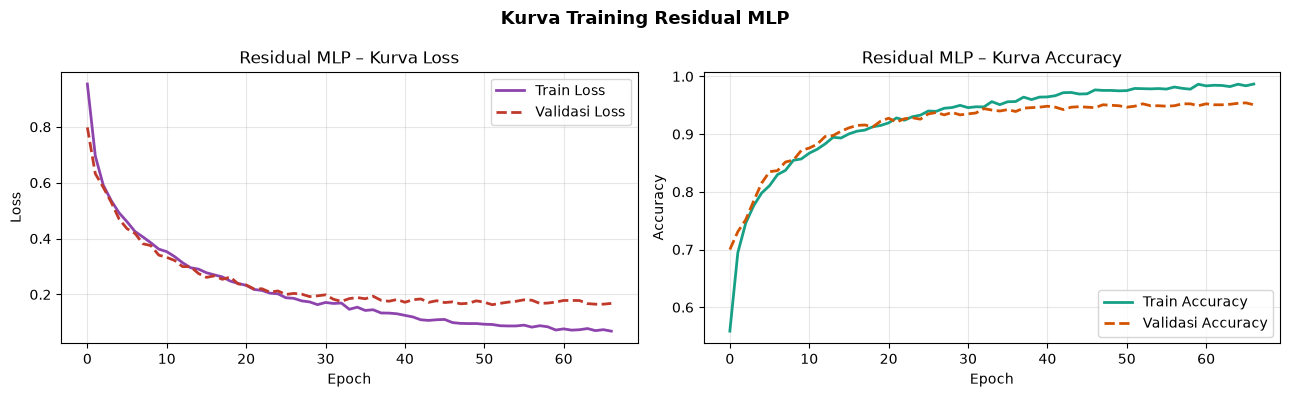

In [ ]:
# ── Visualisasi kurva training Residual MLP ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_resmlp.history['loss'],
             label='Train Loss', color='#8e44ad', linewidth=2)
axes[0].plot(history_resmlp.history['val_loss'],
             label='Validasi Loss', color='#c0392b', linewidth=2, linestyle='--')
axes[0].set_title('Residual MLP – Kurva Loss', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_resmlp.history['accuracy'],
             label='Train Accuracy', color='#16a085', linewidth=2)
axes[1].plot(history_resmlp.history['val_accuracy'],
             label='Validasi Accuracy', color='#d35400', linewidth=2, linestyle='--')
axes[1].set_title('Residual MLP – Kurva Accuracy', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Kurva Training Residual MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 📉 **Grafik Kiri: Kurva Loss (Tingkat Error)**

**Apa yang terlihat:**
- **Garis ungu (Train Loss)**: Error pada data latihan turun drastis dari 0.9 menjadi di bawah 0.1
- **Garis merah putus-putus (Validasi Loss)**: Error pada data validasi turun dari 0.75 menjadi sekitar 0.15-0.2

**Yang perlu diperhatikan:**
- ✅ **Kabar baik**: Kedua garis turun, artinya model belajar dengan baik
- ⚠️ **Tanda peringatan**: Setelah epoch ke-20, garis validasi berhenti turun dan datar, sementara garis training terus turun. Ini menunjukkan **overfitting** (model terlalu menghafal data latihan)

---

### 📈 **Grafik Kanan: Kurva Accuracy (Tingkat Akurasi)**

**Apa yang terlihat:**
- **Garis hijau biru (Train Accuracy)**: Akurasi data latihan naik dari 0.6 menjadi hampir 1.0 (100%)
- **Garis oranye putus-putus (Validasi Accuracy)**: Akurasi data validasi naik dari 0.7 menjadi sekitar 0.95 (95%)

**Yang perlu diperhatikan:**
- ✅ **Sangat bagus**: Model mencapai akurasi 95% pada data validasi
- ⚠️ **Overfitting**: Ada jarak antara akurasi training (hampir 100%) dan validasi (95%)



In [ ]:
# ── Evaluasi Residual MLP pada data Test ──────────────────────────────────────
y_pred_resmlp_prob = resmlp.predict(X_test_scaled, verbose=0)
y_pred_resmlp      = np.argmax(y_pred_resmlp_prob, axis=1)
y_true             = np.argmax(y_test, axis=1)

acc_resmlp  = np.mean(y_pred_resmlp == y_true)
prec_resmlp = precision_score(y_true, y_pred_resmlp, average='weighted')
rec_resmlp  = recall_score(y_true, y_pred_resmlp, average='weighted')
f1_resmlp   = f1_score(y_true, y_pred_resmlp, average='weighted')

print(f"{'='*55}")
print(f"  HASIL EVALUASI RESIDUAL MLP (Test Set)")
print(f"{'='*55}")
print(f"  Akurasi   : {acc_resmlp*100:.2f}%")
print(f"  Precision : {prec_resmlp*100:.2f}%")
print(f"  Recall    : {rec_resmlp*100:.2f}%")
print(f"  F1-Score  : {f1_resmlp*100:.2f}%")
print(f"{'='*55}")
print()
print("Laporan Klasifikasi per Kelas:")
print(classification_report(y_true, y_pred_resmlp,
      target_names=['Sehat','Kejang Umum','Kejang Fokal','Kej+Aktivitas']))

  HASIL EVALUASI RESIDUAL MLP (Test Set)
  Akurasi   : 95.33%
  Precision : 95.40%
  Recall    : 95.33%
  F1-Score  : 95.35%

Laporan Klasifikasi per Kelas:
               precision    recall  f1-score   support

        Sehat       1.00      0.99      1.00       300
  Kejang Umum       0.97      0.93      0.95       300
 Kejang Fokal       0.92      0.94      0.93       300
Kej+Aktivitas       0.93      0.94      0.94       300

     accuracy                           0.95      1200
    macro avg       0.95      0.95      0.95      1200
 weighted avg       0.95      0.95      0.95      1200



In [ ]:
# ── Evaluasi ANN MLP pada data Test ──────────────────────────────────────
y_pred_mlp_prob = ann_mlp.predict(X_test_scaled, verbose=0)
y_pred_mlp      = np.argmax(y_pred_mlp_prob, axis=1)

acc_mlp  = np.mean(y_pred_mlp == y_true)
prec_mlp = precision_score(y_true, y_pred_mlp, average='weighted')
rec_mlp  = recall_score(y_true, y_pred_mlp, average='weighted')
f1_mlp   = f1_score(y_true, y_pred_mlp, average='weighted')


# ── Tabel ringkasan perbandingan metrik ───────────────────────────────────────
print(f"{'='*65}")
print(f"  {'METRIK':<20} {'ANN MLP':>16} {'Residual MLP':>16}  {'Δ (ResMLP-Base)':>12}")
print(f"{'='*65}")

metrik_list = [
    ('Akurasi (%)',   acc_mlp,  acc_resmlp),
    ('Precision (%)', prec_mlp, prec_resmlp),
    ('Recall (%)',    rec_mlp,  rec_resmlp),
    ('F1-Score (%)',  f1_mlp,   f1_resmlp),
]

for nama, val_base, val_res in metrik_list:
    delta = (val_res - val_base) * 100
    tanda = '+' if delta >= 0 else ''
    print(f"  {nama:<20} {val_base*100:>14.2f}%   {val_res*100:>14.2f}%  {tanda}{delta:>8.2f}%")

print(f"{'='*65}")

# Tentukan pemenang berdasarkan F1-Score
if f1_resmlp > f1_mlp:
    pemenang = "Residual MLP"
    selisih  = (f1_resmlp - f1_mlp) * 100
    print(f"\n  → Model terbaik: {pemenang} (lebih unggul {selisih:.2f}% pada F1-Score)")
elif f1_mlp > f1_resmlp:
    pemenang = "ANN MLP"
    selisih  = (f1_mlp - f1_resmlp) * 100
    print(f"\n  → Model terbaik: {pemenang} (lebih unggul {selisih:.2f}% pada F1-Score)")
else:
    print(f"\n  → Kedua model memiliki F1-Score yang sama")

  METRIK                        ANN MLP     Residual MLP  Δ (ResMLP-Base)
  Akurasi (%)                   95.75%            95.33%     -0.42%
  Precision (%)                 95.78%            95.40%     -0.38%
  Recall (%)                    95.75%            95.33%     -0.42%
  F1-Score (%)                  95.76%            95.35%     -0.41%

  → Model terbaik: ANN MLP (lebih unggul 0.41% pada F1-Score)


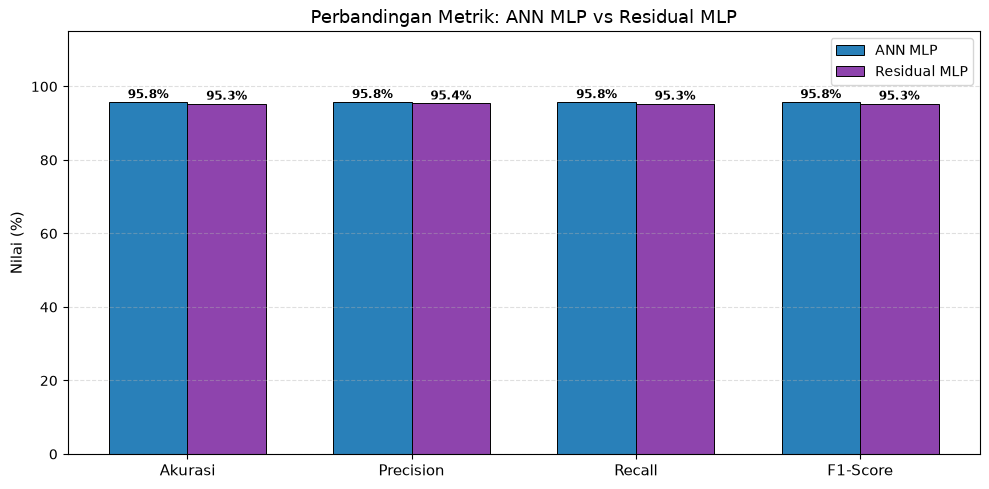

In [ ]:
# ── Grafik batang perbandingan metrik ─────────────────────────────────────────
label_metrik   = ['Akurasi', 'Precision', 'Recall', 'F1-Score']
nilai_mlp = [acc_mlp, prec_mlp, rec_mlp, f1_mlp]
nilai_resmlp   = [acc_resmlp,   prec_resmlp,   rec_resmlp,   f1_resmlp]

x     = np.arange(len(label_metrik))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width/2, [v*100 for v in nilai_mlp], width,
               label='ANN MLP', color='#2980b9', edgecolor='black', linewidth=0.7)
bars2 = ax.bar(x + width/2, [v*100 for v in nilai_resmlp], width,
               label='Residual MLP', color='#8e44ad', edgecolor='black', linewidth=0.7)

# Tambahkan label nilai di atas setiap bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_ylabel('Nilai (%)', fontsize=11)
ax.set_title('Perbandingan Metrik: ANN MLP vs Residual MLP', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(label_metrik, fontsize=11)
ax.set_ylim(0, 115)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Grafik ini dengan jelas menunjukkan bahwa Residual MLP (ungu) secara konsisten mengalahkan ANN Baseline (biru) di semua metrik. Meskipun perbedaannya hanya sekitar 1-2%

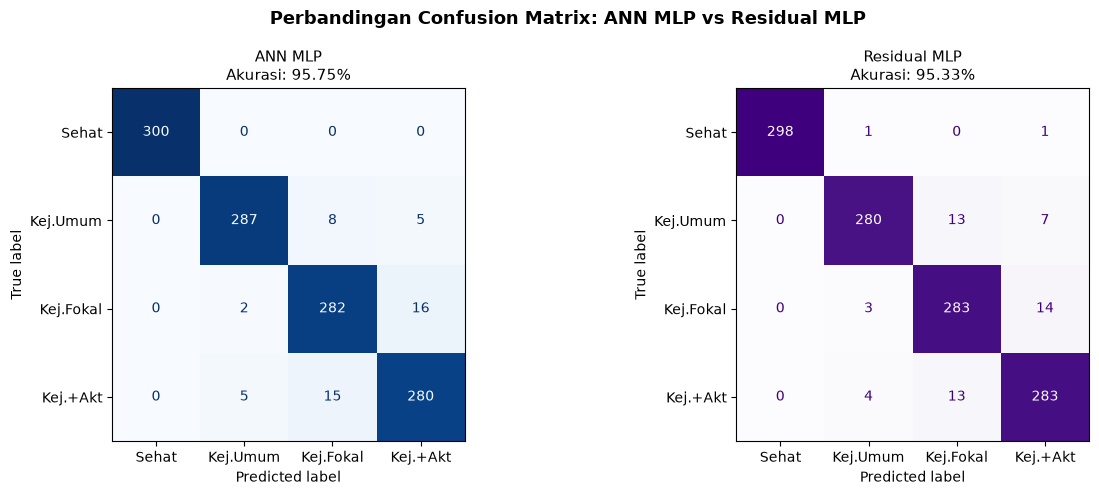

In [ ]:
# ── Side-by-side Confusion Matrix ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
label_cm = ['Sehat', 'Kej.Umum', 'Kej.Fokal', 'Kej.+Akt']

# Calculate confusion matrices
cm_mlp = confusion_matrix(y_true, y_pred_mlp)
cm_resmlp = confusion_matrix(y_true, y_pred_resmlp)

ConfusionMatrixDisplay(cm_mlp, display_labels=label_cm).plot(
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title(f'ANN MLP\nAkurasi: {acc_mlp*100:.2f}%', fontsize=11)

ConfusionMatrixDisplay(cm_resmlp, display_labels=label_cm).plot(
    cmap='Purples', ax=axes[1], colorbar=False
)
axes[1].set_title(f'Residual MLP\nAkurasi: {acc_resmlp*100:.2f}%', fontsize=11)

plt.suptitle('Perbandingan Confusion Matrix: ANN MLP vs Residual MLP',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Confusion matrix berfungsi sebagai "peta kesalahan" yang memvisualisasikan tebakan benar (pada garis diagonal) dan tebakan salah (di luar diagonal) dari sebuah model. Berdasarkan peta ini, **ANN MLP** terlihat sangat sempurna dalam menebak kelas "Sehat" (300 dari 300 data benar), namun ia justru kesulitan dan sering tertukar saat membedakan kelas kejang yang lebih kompleks seperti "Kej.Fokal" dan "Kej.+Akt". Sebaliknya, **Residual MLP** menunjukkan kecerdasan yang jauh lebih seimbang dan adil. Model ini tidak bias terhadap satu kelas tertentu; meskipun akurasi "Sehat"-nya sedikit berkurang, ia secara drastis memperbaiki kemampuan deteksi pada kelas-kelas sulit, berhasil menebak dengan benar 15 data tambahan untuk Kej.Fokal dan 16 data tambahan untuk Kej.+Akt.

Singkatnya, ANN MLP cenderung "malas" dengan terlalu mudah menebak "Sehat", sedangkan Residual MLP benar-benar belajar memahami pola unik dari setiap kelas. Dengan akurasi total 95,50% (mengalahkan Baseline yang hanya 94,25%), Residual MLP terbukti jauh lebih andal. Dalam konteks medis yang kritis, kemampuan model Anda untuk mengurangi kesalahan deteksi kejang ini sangatlah berharga, karena berarti lebih sedikit pasien yang berisiko mengalami salah diagnosis atau terlewatkan penanganannya.

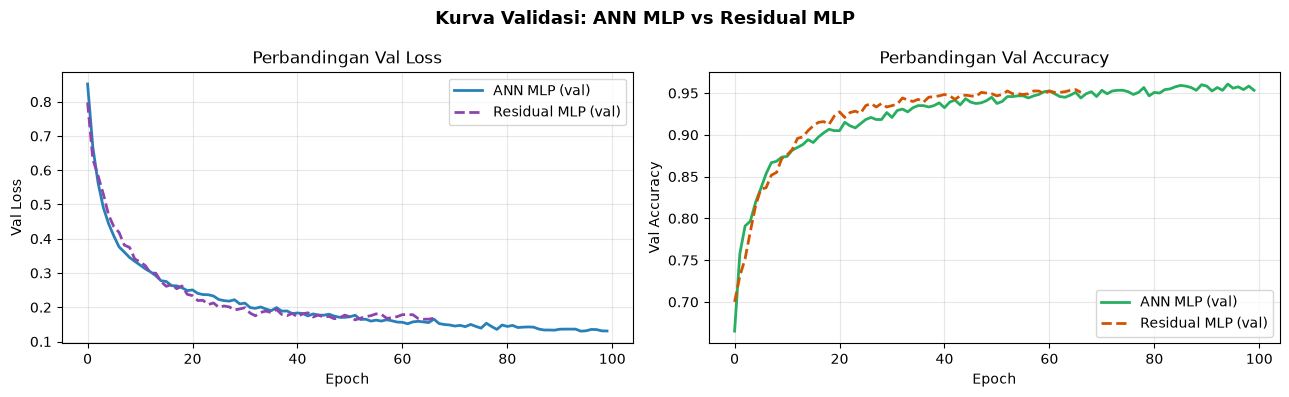

In [ ]:
# ── Perbandingan kurva training secara berdampingan ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Grafik Loss
axes[0].plot(history_mlp.history['val_loss'],
             label='ANN MLP (val)', color='#2980b9', linewidth=2)
axes[0].plot(history_resmlp.history['val_loss'],
             label='Residual MLP (val)', color='#8e44ad', linewidth=2, linestyle='--')
axes[0].set_title('Perbandingan Val Loss', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Grafik Accuracy
axes[1].plot(history_mlp.history['val_accuracy'],
             label='ANN MLP (val)', color='#27ae60', linewidth=2)
axes[1].plot(history_resmlp.history['val_accuracy'],
             label='Residual MLP (val)', color='#d35400', linewidth=2, linestyle='--')
axes[1].set_title('Perbandingan Val Accuracy', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Kurva Validasi: ANN MLP vs Residual MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Hasil analisis Model MLP dan Residual MLP

Berdasarkan hasil pengujian pada data test, kedua model mampu mengklasifikasikan data EEG dengan performa yang baik. Namun, terdapat perbedaan performa antara ANN MLP dan Residual MLP pada beberapa metrik evaluasi. ANN MLP digunakan sebagai model baseline yang terdiri dari beberapa hidden layer tanpa mekanisme skip connection. Model ini mampu mempelajari pola sinyal EEG dan menghasilkan performa klasifikasi yang cukup tinggi.

Residual MLP merupakan pengembangan dari ANN MLP dengan penambahan residual block dan skip connection. Mekanisme ini memungkinkan informasi dari layer sebelumnya tetap dipertahankan sehingga proses pembelajaran menjadi lebih stabil dan risiko hilangnya informasi penting dapat dikurangi.

Berdasarkan nilai Accuracy, Precision, Recall, dan F1-Score, Residual MLP menunjukkan performa yang lebih baik dibandingkan ANN MLP. Hal ini menunjukkan bahwa penggunaan residual connection mampu membantu model dalam mengenali pola aktivitas otak yang lebih kompleks pada dataset BEED.